
# Alignment Benchmarking Script

*Author: [Andrew Causer](https://agc888.github.io/OspreyAI)*

This notebook contains scripts used for the publication of [`goatpy: Specialised Spatial Glycomics Analysis Toolkit`](). For full tutorials on how to use *goatpy* please visit the getting started vignette on the [*goatpy* website](https://goatpy.readthedocs.io/en/latest/guides/getting_started.html#).

In [1]:
import goatpy as gp
import spatialdata_plot
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
import squidpy as sq
from napari_spatialdata import Interactive

/Users/andrewcauser/goatpy/goatpy/io.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


## Manual Alignment Method

In [2]:
## Load Data
path = "/Users/andrewcauser/Documents/Griffith/AD_resolution_change_check_10um_actual_10012020_2.imzML"
he_path = "/Users/andrewcauser/Documents/Griffith/res_check_0000.tif"

maldi_sd = gp.glyco_spatialdata(imzml_path=path)
he_sd = gp.he_spatialdata(he_path)

## Cluster data
maldi_sd = gp.graphpca_spatialdata(maldi_sd, tables= "maldi_adata",
    library_id= 'spatial',
    n_components = 50, 
    n_neighbors = 15,
    alpha = 0.5)

maldi_sd = gp.get_kmean_clusters(maldi_sd, tables= "maldi_adata",n_clusters = 12) 

## Add pseudo-image
maldi_sd = gp.Add_Pseudo_Image(maldi_sd, "MPI", tables = "maldi_adata", library_id = "Spatial", is_continous=True, cmap = "viridis",img_upscaling=50)

he_sd = gp.add_annotations(he_sd, geojson_path = "/Users/andrewcauser/Documents/Griffith/res_check_0000.tif - Series 0.geojson")

## Add pre-defined manual alignment landmark coordinates
from spatialdata.models import PointsModel
import pandas as pd

maldi_align_points = pd.DataFrame({
    "x": [5404.308411,264.272160,86.940332,2868.641138,4373.852380,3789.372648],
    "y": [300.995356,229.934947,12260.275212,7766.730516,3316.797739,2786.869449]
})

he_align_points = pd.DataFrame({
    "x": [21122.827939,16978.181195,16774.458098,19095.959080,20299.401265,19810.152565],
    "y": [8758.906989,8691.239287,18177.396284,14541.463462,11072.194365,10678.050002]
})

maldi_sd["maldi_landmarks"] = PointsModel.parse(maldi_align_points)
he_sd["he_landmarks"] = PointsModel.parse(he_align_points)

## Add pathologist annotation to H&E

## Run Manual Alignment
manual = gp.align_image_using_landmarks(maldi_sd, he_sd)


/Users/andrewcauser/goatpy/goatpy/io.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/andrewcauser/goatpy/goatpy/io.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/andrewcauser/goatpy/goatpy/io.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/andrewcauser/goatpy/goatpy/io.py:7: UserWarning: pkg_resources is dep

INFO     Transposing `data` of type: <class 'dask.array.core.Array'> to ('c', 'y', 'x').                           


/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/spatialdata/_core/_elements.py:128: UserWarning: Key `maldi_adata` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


## Automatic alignment

In [3]:
automatic = gp.load_and_align(imzml_path = "/Users/andrewcauser/Documents/Griffith/AD_resolution_change_check_10um_actual_10012020_2.imzML",
                          he_path="/Users/andrewcauser/Documents/Griffith/res_check_0000.tif",
                          geojson_path="/Users/andrewcauser/Documents/Griffith/res_check_0000.tif - Series 0.geojson")

/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession MS:1002302 found with incorrect name "Bruker Container file". Updating name to "Bruker Container format".
  warn(
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession IMS:1000046 found with incorrect name "pixel size". Updating name to "pixel size (x)".
  warn(


[3.90GB] Loading peaks ...
[3.90GB]   108 peaks
[3.90GB]   WARNING: H&E pixel size unknown, assuming 0.2527 um/px.
[3.90GB]   MALDI pixel size from imzML metadata: 400.0 um/px
[3.90GB]   WARNING: imzML pixel size 400.0 um makes ref thumbnail (15x12 px) smaller than MALDI (2760x1126 px) -- likely wrong.
[3.90GB]   Falling back to maldi_pixel_um=10.0 um/px.
[3.90GB]   maldi_pixel_um=10.0  ref_pixel_um=0.2527
[3.90GB] Computing MALDI crop offsets ...
[0.92GB]   Crop: row=877, col=2638
[1.14GB] Loading 108 ion images (chunk=10) with 0.1 Da tolerance per peak ...


/Users/andrewcauser/goatpy/goatpy/io.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/andrewcauser/goatpy/goatpy/io.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/andrewcauser/goatpy/goatpy/io.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/andrewcauser/goatpy/goatpy/io.py:7: UserWarning: pkg_resources is dep

[0.38GB]   Peaks 1-10 / 108
[0.37GB]   Peaks 11-20 / 108
[0.35GB]   Peaks 21-30 / 108
[0.38GB]   Peaks 31-40 / 108
[0.38GB]   Peaks 41-50 / 108
[0.36GB]   Peaks 51-60 / 108
[0.34GB]   Peaks 61-70 / 108
[0.34GB]   Peaks 71-80 / 108
[0.34GB]   Peaks 81-90 / 108
[0.35GB]   Peaks 91-100 / 108
[0.38GB]   Peaks 101-108 / 108
[0.39GB]   spectra_all: (249, 122, 108)  (13 MB)
[0.39GB] Preparing MALDI template ...
[0.40GB]   MALDI grayscale: (249, 122)  mean=0.190
[0.68GB] Loading H&E at 10.0 um/px ...
[1.01GB]   PIL: 23633x19160
[0.46GB]   Resized to 597x484  10.000 um/px  (1 MB)
[0.46GB]   H&E: 597x484  (1 MB)
[0.46GB] Preparing H&E registration image ...
[0.46GB]   H&E grayscale: (484, 597)  mean=0.104
[0.47GB] Running registration ...
[0.47GB]   Coarse: 24 rotations (0-360 step 15) ...
[0.49GB]       0.0  score=0.7967
[0.51GB]      15.0  score=0.5699
[0.52GB]      30.0  score=0.5916
[0.54GB]      45.0  score=0.5555
[0.55GB]      60.0  score=0.5249
[0.55GB]      75.0  score=0.5478
[0.56GB]   

/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


[1.32GB]   Annotations added -> sdata.shapes['annotations']
[1.32GB]   Transform stored: mode=he  rotation=1.0  ref_reg_size=[484, 597]  canvas_placement=[75, 75]
[1.32GB] Done.


## Add Annotaitons to anndata

In [4]:
automatic = gp.annotations_to_pixels(sdata = automatic, shapes_key = "annotations",  coordinate_system = "global")
manual = gp.annotations_to_pixels(sdata = manual, shapes_key = "Annotations",  coordinate_system = "aligned")

  'Tumor': 5,644 pixels

  'annotation' added: 5,644 / 30,378 pixels annotated (18.6%)
    'other'                       :   24,734  (81.4%)
    'Tumor'                       :    5,644  (18.6%)
  'Tumor': 5,540 pixels

  'annotation' added: 5,540 / 16,455 pixels annotated (33.7%)
    'other'                       :   10,915  (66.3%)
    'Tumor'                       :    5,540  (33.7%)


## Spatial Visualisation

INFO     Rasterizing image for faster rendering.                                                                   
INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                


/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/spatialdata/_core/_elements.py:108: UserWarning: Key `pixels` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/spatialdata/_core/_elements.py:128: UserWarning: Key `maldi_adata` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


INFO     Using the datashader reduction "mean". "max" will give an output very close to the matplotlib result.     
INFO     Rasterizing image for faster rendering.                                                                   
INFO     Rasterizing image for faster rendering.                                                                   


/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/spatialdata_plot/pl/utils.py:800: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)


INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                


/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/spatialdata/_core/_elements.py:108: UserWarning: Key `pixels` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/spatialdata/_core/_elements.py:128: UserWarning: Key `maldi_adata` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


INFO     Using the datashader reduction "mean". "max" will give an output very close to the matplotlib result.     
INFO     Rasterizing image for faster rendering.                                                                   


/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/spatialdata_plot/pl/utils.py:800: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)


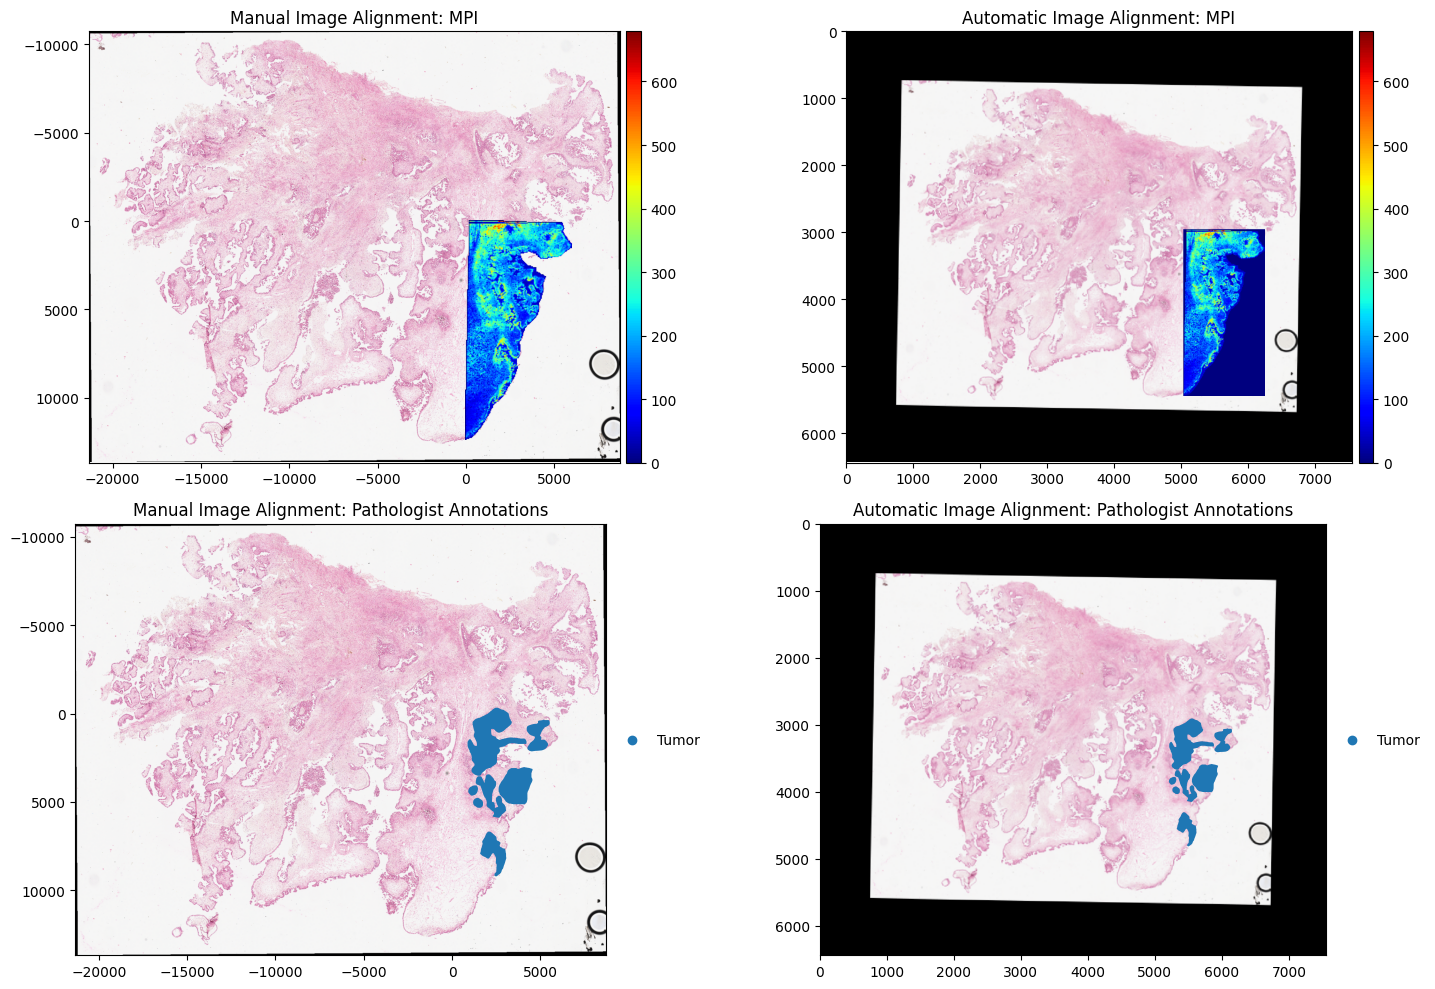

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

manual.pl.render_images("he_image") \
       .pl.render_shapes("pixels", color = "MPI", cmap = "jet")\
       .pl.show("aligned", ax=axes[0,0],title = "Manual Image Alignment: MPI")

manual.pl.render_images("he_image") \
       .pl.render_shapes("Annotations", color = "classification")\
       .pl.show("aligned", ax=axes[1,0],title = "Manual Image Alignment: Pathologist Annotations")


automatic.pl.render_images("he_image") \
       .pl.render_shapes("pixels", color = "MPI", cmap = "jet")\
       .pl.show("global", ax=axes[0,1],title = "Automatic Image Alignment: MPI")


automatic.pl.render_images("he_image") \
       .pl.render_shapes("annotations", color = "classification")\
       .pl.show("global", ax=axes[1,1],title = "Automatic Image Alignment: Pathologist Annotations")

plt.tight_layout()
plt.show()


## Annotate Glycans

In [6]:
manual = gp.annotate_glycans(manual)
automatic = gp.annotate_glycans(automatic)

/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/andrewcauser/goatpy/goatpy/tools.py:208: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df.groupby(
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/spatialdata/_core/_elements.py:128: UserWarning: Key `maldi_adata` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/Users/andrewcauser/goatpy/goatpy/tools.py:208: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame


Annotation Statistics
----------------------------------------
total_peaks: 108
annotated_peaks: 56
unannotated_peaks: 52
multi_annotation_peaks: 1
unique_glycans: 56
duplicate_glycans: 1
annotation_rate: 51.85

Duplicate Glycans
----------------------------------------
H5N4S1F1 (underivitised): mz-2100.7, mz-2122.7

Annotation Statistics
----------------------------------------
total_peaks: 108
annotated_peaks: 56
unannotated_peaks: 52
multi_annotation_peaks: 1
unique_glycans: 56
duplicate_glycans: 1
annotation_rate: 51.85

Duplicate Glycans
----------------------------------------
H5N4S1F1 (underivitised): 2100.7, 2122.7


/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/spatialdata/_core/_elements.py:128: UserWarning: Key `maldi_adata` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


## Differential abundance analysis

/var/folders/f1/3f7gj1393nb0phh8vzn910nm0000gn/T/ipykernel_68426/1693720318.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("group")


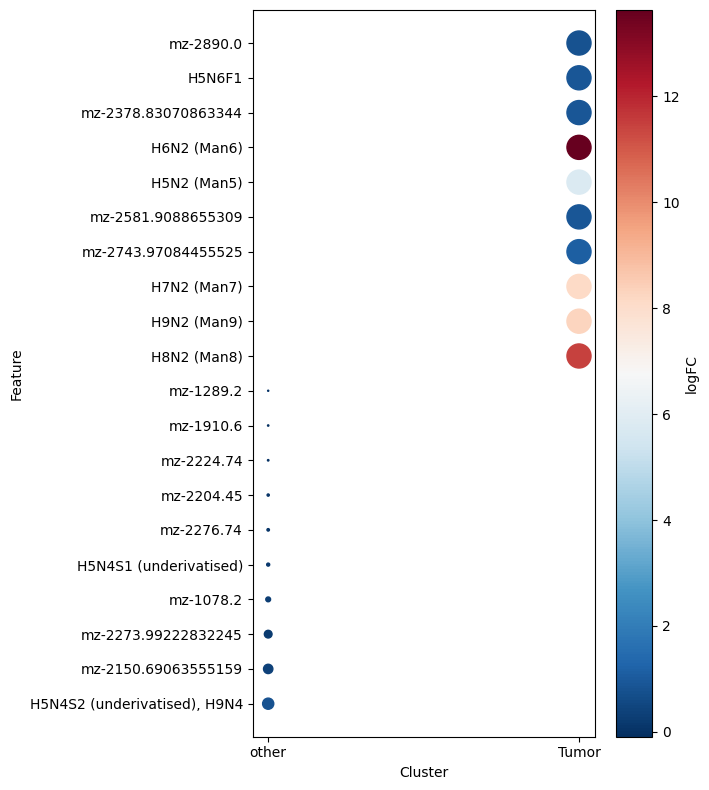

In [ ]:
sc.tl.rank_genes_groups(manual["maldi_adata"], groupby='annotation', method='wilcoxon')
de_results = sc.get.rank_genes_groups_df(manual["maldi_adata"], group=None)

import numpy as np
import matplotlib.pyplot as plt

n_top = 10

top_markers = (
    de_results
    .sort_values(["group", "scores"], ascending=[True, False])
    .groupby("group")
    .head(n_top)
    .copy()
)

top_markers["minus_log10_p"] = -np.log10(
    top_markers["pvals_adj"].clip(lower=1e-300)
)

plt.figure(figsize=(7, 8))

scatter = plt.scatter(
    x=top_markers["group"],
    y=top_markers["names"],
    s=top_markers["minus_log10_p"],
    c=top_markers["logfoldchanges"],
    cmap="RdBu_r"
)

plt.colorbar(scatter, label="logFC")
plt.xlabel("Cluster")
plt.ylabel("Feature")


plt.tight_layout()
plt.show()

/var/folders/f1/3f7gj1393nb0phh8vzn910nm0000gn/T/ipykernel_68426/1757414759.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("group")


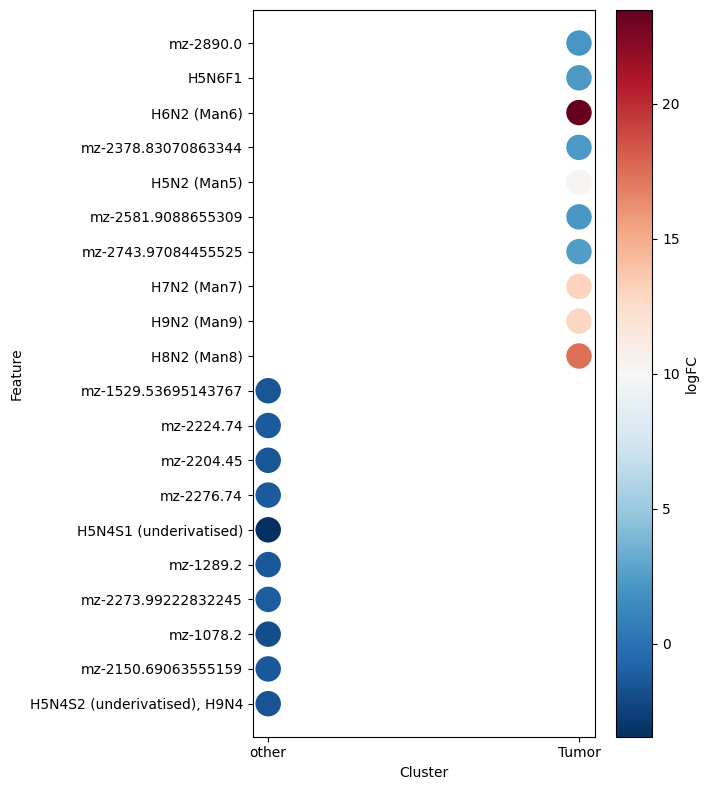

In [ ]:
sc.tl.rank_genes_groups(automatic["maldi_adata"], groupby='annotation', method='wilcoxon')
de_results = sc.get.rank_genes_groups_df(automatic["maldi_adata"], group=None)

import numpy as np
import matplotlib.pyplot as plt

n_top = 10

top_markers = (
    de_results
    .sort_values(["group", "scores"], ascending=[True, False])
    .groupby("group")
    .head(n_top)
    .copy()
)

top_markers["minus_log10_p"] = -np.log10(
    top_markers["pvals_adj"].clip(lower=1e-300)
)

plt.figure(figsize=(7, 8))

scatter = plt.scatter(
    x=top_markers["group"],
    y=top_markers["names"],
    s=top_markers["minus_log10_p"],
    c=top_markers["logfoldchanges"],
    cmap="RdBu_r"
)

plt.colorbar(scatter, label="logFC")
plt.xlabel("Cluster")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()